# Modelo - Copa do Mundo 2026

Organizacao:
1. Imports e constantes
2. Carga de dados
3. Engenharia de features
4. Treino e avaliacao
5. Eliminatorias (CONMEBOL e UEFA)
6. Ranking final

In [130]:
from pathlib import Path
import unicodedata

import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix, ConfusionMatrixDisplay, RocCurveDisplay
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE

RANDOM_STATE = 42
DATA_DIR = Path("dados_ciclo_basic")

In [131]:
decision = pd.read_csv(DATA_DIR / "decision.csv.csv")
results = pd.read_csv(DATA_DIR / "FIFA Results.csv")
penal = pd.read_csv(DATA_DIR / "penality kick.csv.csv")
rank = pd.read_csv(DATA_DIR / "Fifa_ranking_2022-10-06.csv")
dados_copa = pd.read_csv(DATA_DIR / "world_cup.csv")
match_results = pd.read_csv(DATA_DIR / "matches_1930_2022.csv")

## 1) Imports e constantes

In [132]:
def normalize_team(name: str) -> str:
    if pd.isna(name):
        return name
    normalized = unicodedata.normalize("NFKD", str(name))
    normalized = "".join(ch for ch in normalized if not unicodedata.combining(ch))
    return normalized.strip().lower()

## 2) Carga de dados

In [133]:
match_results = match_results.rename(columns={'Date': 'date'})

match_results['date'] = pd.to_datetime(match_results['date'])
decision['date'] = pd.to_datetime(decision['date'])

merged_df = pd.merge(
    match_results,
    decision,
    on=['date', 'home_team', 'away_team', 'home_score', 'away_score'],
    how='left'  
)

In [134]:
merged_df['date'] = pd.to_datetime(merged_df['date'])
merged_df['year'] = merged_df['date'].dt.year

home_df = merged_df[[
    'home_team', 'away_team', 'home_score', 'away_score',
    'home_xg', 'away_xg', 'year'
]].copy()
home_df.columns = ['team', 'opponent', 'goals_for', 'goals_against', 'xg_for', 'xg_against', 'year']

away_df = merged_df[[
    'away_team', 'home_team', 'away_score', 'home_score',
    'away_xg', 'home_xg', 'year'
]].copy()
away_df.columns = ['team', 'opponent', 'goals_for', 'goals_against', 'xg_for', 'xg_against', 'year']

long_df = pd.concat([home_df, away_df], ignore_index=True)

team_stats = long_df.groupby(['team', 'year']).agg({
    'goals_for': 'sum',
    'goals_against': 'sum',
    'xg_for': 'sum',
    'xg_against': 'sum',
    'opponent': 'count'  # número de jogos
}).rename(columns={'opponent': 'matches'}).reset_index()


In [135]:
match_results = match_results.rename(columns={'Year': 'year'})

In [136]:
home_results = match_results[['home_team', 'home_score', 'away_score', 'year']].copy()
home_results.rename(columns={'home_team':'team', 'home_score':'goals_for', 'away_score':'goals_against'}, inplace=True)

away_results = match_results[['away_team', 'away_score', 'home_score', 'year']].copy()
away_results.rename(columns={'away_team':'team', 'away_score':'goals_for', 'home_score':'goals_against'}, inplace=True)

all_results = pd.concat([home_results, away_results], ignore_index=True)

def get_result(row):
    if row['goals_for'] > row['goals_against']:
        return 'win'
    elif row['goals_for'] == row['goals_against']:
        return 'draw'
    else:
        return 'loss'

all_results['result'] = all_results.apply(get_result, axis=1)

stats = all_results.groupby(['team', 'year'])['result'].value_counts().unstack(fill_value=0)

stats['matches'] = stats.sum(axis=1)
stats['win_rate'] = stats['win'] / stats['matches']

print(stats.head())

team_stats = team_stats.merge(stats[['matches', 'win', 'draw', 'loss','win_rate']], on=['team', 'year'], how='left')


result        draw  loss  win  matches  win_rate
team    year                                    
Algeria 1982     0     1    2        3  0.666667
        1986     1     2    0        3  0.000000
        2010     1     2    0        3  0.000000
        2014     1     2    1        4  0.250000
Angola  2006     2     1    0        3  0.000000


In [137]:
team_stats = team_stats.merge(
    dados_copa[['Year', 'Champion']],
    left_on='year',
    right_on='Year',
    how='left'
)

team_stats['champion'] = (team_stats['team'] == team_stats['Champion']).astype(int)

team_stats.drop(columns=['Champion', 'Year'], inplace=True)

team_stats.head()

,team,year,goals_for,goals_against,xg_for,xg_against,matches_x,matches_y,win,draw,loss,win_rate,champion
0,Algeria,1982,5,5,0.0,0.0,3,3,2,0,1,0.666667,0
1,Algeria,1986,1,5,0.0,0.0,3,3,0,1,2,0.000000,0
2,Algeria,2010,0,2,0.0,0.0,3,3,0,1,2,0.000000,0
3,Algeria,2014,7,7,0.0,0.0,4,4,1,1,2,0.250000,0
4,Angola,2006,1,2,0.0,0.0,3,3,0,2,1,0.000000,0


In [138]:
team_stats = team_stats.merge(
    dados_copa[['Year', 'Host']],
    left_on='year',
    right_on='Year',
    how='left'
)
team_stats.drop(columns='Year', inplace=True)

print(team_stats[['team', 'year', 'Host']].drop_duplicates().sort_values('year'))

              team  year     Host
50         Bolivia  1930  Uruguay
313       Paraguay  1930  Uruguay
444  United States  1930  Uruguay
321           Peru  1930  Uruguay
264         Mexico  1930  Uruguay
..             ...   ...      ...
249          Japan  2022    Qatar
144        Ecuador  2022    Qatar
454  United States  2022    Qatar
297    Netherlands  2022    Qatar
431    Switzerland  2022    Qatar

[489 rows x 3 columns]


In [139]:
team_stats['matches'] = team_stats['matches_y']

team_stats.drop(columns=['matches_x', 'matches_y'], inplace=True)

In [140]:
decision['date'] = pd.to_datetime(decision['date'])
decision['year'] = decision['date'].dt.year

home_d = decision[['home_team', 'away_team', 'tournament', 'city', 'country', 'neutral', 'year']].copy()
home_d.columns = ['team', 'opponent', 'tournament', 'city', 'country', 'neutral', 'year']

away_d = decision[['away_team', 'home_team', 'tournament', 'city', 'country', 'neutral', 'year']].copy()
away_d.columns = ['team', 'opponent', 'tournament', 'city', 'country', 'neutral', 'year']

decision_long = pd.concat([home_d, away_d], ignore_index=True)

decision_agg = decision_long.groupby(['team', 'year']).agg({
    'neutral': 'mean',         # % de jogos em campo neutro
    'tournament': lambda x: x.mode().iloc[0] if not x.mode().empty else None,
    'country': lambda x: x.mode().iloc[0] if not x.mode().empty else None,
}).reset_index()

decision_agg.rename(columns={'neutral': 'pct_neutral_games'}, inplace=True)

## 3) Engenharia de features

In [141]:
team_stats['goal_difference'] = team_stats['goals_for'] - team_stats['goals_against']
team_stats['avg_goals_for'] = team_stats['goals_for'] / team_stats['matches']
team_stats['avg_goals_against'] = team_stats['goals_against'] / team_stats['matches']
team_stats['goal_ratio'] = team_stats['goals_for'] / (team_stats['goals_against'] + 1e-5)
team_stats['xg_difference'] = team_stats['xg_for'] - team_stats['xg_against']
team_stats['avg_xg_for'] = team_stats['xg_for'] / team_stats['matches']

In [142]:
team_stats = team_stats.merge(
    decision_agg,
    on=['team', 'year'],
    how='left'
)

In [144]:
team_stats = team_stats.drop(columns=['country'])

In [145]:
team_stats = team_stats[
    team_stats['tournament'].isin(['FIFA World Cup qualification', 'FIFA World Cup', ])
].copy()
team_stats['is_host'] = (team_stats['team'] == team_stats['Host']).astype(int)


worldcup_2022_teams = pd.concat([
    decision[(decision['year'] == 2022) & (decision['tournament'].str.contains("World Cup", case=False))]['home_team'],
    decision[(decision['year'] == 2022) & (decision['tournament'].str.contains("World Cup", case=False))]['away_team']
]).unique()

team_stats = team_stats[team_stats['team'].isin(worldcup_2022_teams)]

In [146]:
team_stats.head()

,team,year,goals_for,goals_against,xg_for,xg_against,win,draw,loss,win_rate,...,matches,goal_difference,avg_goals_for,avg_goals_against,goal_ratio,xg_difference,avg_xg_for,pct_neutral_games,tournament,is_host
5,Argentina,1930,18,9,0.0,0.0,4,0,1,0.800000,...,5,9,3.600000,1.800000,1.999998,0.0,0.0,0.571429,FIFA World Cup,0
8,Argentina,1962,2,3,0.0,0.0,1,1,1,0.333333,...,3,-1,0.666667,1.000000,0.666664,0.0,0.0,0.375000,FIFA World Cup,0
9,Argentina,1966,4,2,0.0,0.0,2,1,1,0.500000,...,4,2,1.000000,0.500000,1.999990,0.0,0.0,0.500000,FIFA World Cup,0
10,Argentina,1974,9,12,0.0,0.0,1,2,3,0.166667,...,6,-3,1.500000,2.000000,0.749999,0.0,0.0,0.461538,FIFA World Cup,0
11,Argentina,1978,15,4,0.0,0.0,5,1,1,0.714286,...,7,11,2.142857,0.571429,3.749991,0.0,0.0,0.000000,FIFA World Cup,1


In [147]:
features = [
    'goals_for',
    'goals_against',
    'win',
    'draw',
    'loss',
    'win_rate',
    'goal_difference',
    'avg_goals_for',
    'avg_goals_against',
    'goal_ratio',
]

## 4) Treino e avaliacao

In [148]:
team_stats.columns

Index(['team', 'year', 'goals_for', 'goals_against', 'xg_for', 'xg_against',
       'win', 'draw', 'loss', 'win_rate', 'champion', 'Host', 'matches',
       'goal_difference', 'avg_goals_for', 'avg_goals_against', 'goal_ratio',
       'xg_difference', 'avg_xg_for', 'pct_neutral_games', 'tournament',
       'is_host'],
      dtype='object')

In [149]:
team_stats.drop(columns=['xg_for', 'xg_against', 'xg_difference','avg_xg_for','is_host', 'pct_neutral_games', 'tournament', 'is_host', 'matches', 'Host'], inplace=True)

=== Relatório de Classificação (Teste) ===
              precision    recall  f1-score   support

           0       0.97      0.97      0.97        34
           1       0.80      0.80      0.80         5

    accuracy                           0.95        39
   macro avg       0.89      0.89      0.89        39
weighted avg       0.95      0.95      0.95        39


=== Importância das Features ===
loss                 0.290771
goal_difference      0.213723
win                  0.134826
goal_ratio           0.122850
win_rate             0.092306
goals_for            0.077150
avg_goals_for        0.024288
draw                 0.018105
avg_goals_against    0.014102
goals_against        0.011879
dtype: float64


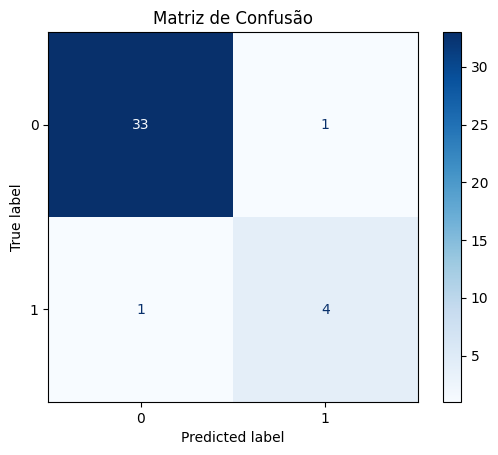

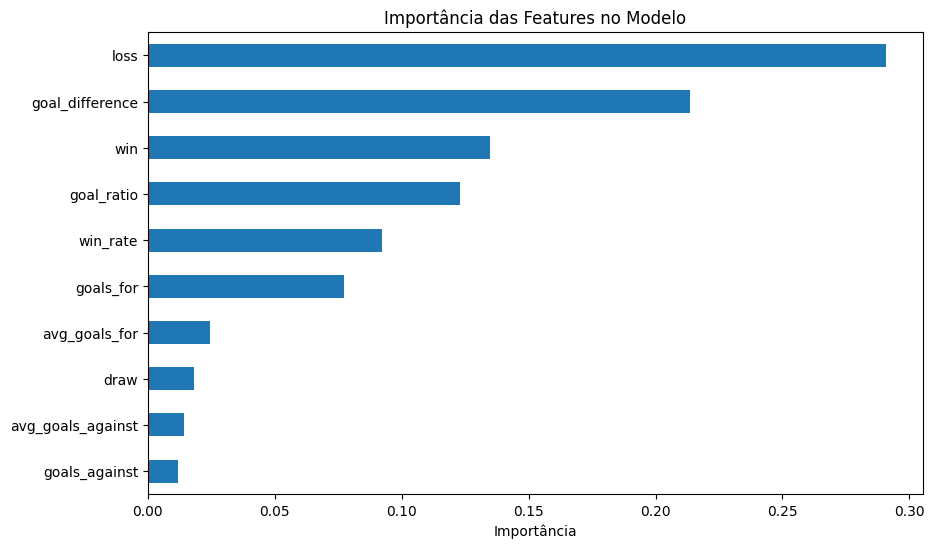

In [150]:
for col in features:
    median = team_stats[col].median()
    team_stats[col] = team_stats[col].fillna(median)

team_stats = team_stats.dropna(subset=['champion'])

X = team_stats[features]
y = team_stats['champion']

if y.nunique() < 2:
    raise ValueError("A coluna 'champion' precisa ter pelo menos duas classes.")

class_counts = y.value_counts()
use_stratify = class_counts.min() >= 2

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=RANDOM_STATE,
    stratify=y if use_stratify else None,
)

# Padronização dos dados
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Balanceamento com SMOTE (somente se a classe minoritária tiver >= 2 exemplos)
if class_counts.min() >= 2:
    smote = SMOTE(random_state=RANDOM_STATE)
    X_train_bal, y_train_bal = smote.fit_resample(X_train_scaled, y_train)
else:
    X_train_bal, y_train_bal = X_train_scaled, y_train

# Treinamento do modelo base (Random Forest)
model = RandomForestClassifier(
    n_estimators=300,
    max_depth=5,
    min_samples_split=10,
    random_state=RANDOM_STATE,
)
model.fit(X_train_bal, y_train_bal)

y_pred = model.predict(X_test_scaled)
print("=== Relatório de Classificação (Teste) ===")
print(classification_report(y_test, y_pred))

importances = model.feature_importances_
importance_series = pd.Series(importances, index=features).sort_values(ascending=False)
print("\n=== Importância das Features ===")
print(importance_series)

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.title("Matriz de Confusão")
plt.show()

plt.figure(figsize=(10, 6))
importance_series.plot(kind='barh')
plt.xlabel("Importância")
plt.title("Importância das Features no Modelo")
plt.gca().invert_yaxis()
plt.show()


## 5) Eliminatorias (dados manuais)

In [151]:
def avaliar_modelo(nome, clf, X_train, X_test, y_train, y_test):
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    acc = (y_pred == y_test).mean()

    if hasattr(clf, "predict_proba"):
        y_proba = clf.predict_proba(X_test)[:, 1]
        auc = roc_auc_score(y_test, y_proba)
    else:
        auc = np.nan

    print(f"{nome}: accuracy={acc:.3f} | roc_auc={auc:.3f}")


modelos = {
    "LogisticRegression": Pipeline(
        steps=[
            ("scaler", StandardScaler()),
            ("clf", LogisticRegression(max_iter=1000, class_weight="balanced", random_state=RANDOM_STATE)),
        ]
    ),
    "GradientBoosting": GradientBoostingClassifier(random_state=RANDOM_STATE),
    "RandomForest": RandomForestClassifier(
        n_estimators=300,
        max_depth=5,
        min_samples_split=10,
        random_state=RANDOM_STATE,
    ),
}

print("=== Comparativo de Modelos (teste) ===")
for nome, clf in modelos.items():
    avaliar_modelo(nome, clf, X_train, X_test, y_train, y_test)

=== Comparativo de Modelos (teste) ===
LogisticRegression: accuracy=0.897 | roc_auc=0.965
GradientBoosting: accuracy=0.897 | roc_auc=0.894
RandomForest: accuracy=0.949 | roc_auc=0.959


In [152]:
stats_eliminatorias_conmebol = {
    "Argentina": {"jogos": 18, "vitorias": 12, "empates": 2, "derrotas": 4, "gols_pro": 31, "gols_contra": 10, "saldo": 21, "pontos": 38},
    "Equador": {"jogos": 18, "vitorias": 8, "empates": 8, "derrotas": 2, "gols_pro": 14, "gols_contra": 5, "saldo": 9, "pontos": 29},
    "Colombia": {"jogos": 18, "vitorias": 7, "empates": 7, "derrotas": 4, "gols_pro": 28, "gols_contra": 18, "saldo": 10, "pontos": 28},
    "Uruguai": {"jogos": 18, "vitorias": 7, "empates": 7, "derrotas": 4, "gols_pro": 22, "gols_contra": 12, "saldo": 10, "pontos": 28},
    "Brasil": {"jogos": 18, "vitorias": 8, "empates": 4, "derrotas": 6, "gols_pro": 24, "gols_contra": 17, "saldo": 7, "pontos": 28},
    "Paraguai": {"jogos": 18, "vitorias": 7, "empates": 7, "derrotas": 4, "gols_pro": 14, "gols_contra": 10, "saldo": 4, "pontos": 28},
    "Bolivia": {"jogos": 18, "vitorias": 6, "empates": 2, "derrotas": 10, "gols_pro": 17, "gols_contra": 35, "saldo": -18, "pontos": 20},
    "Venezuela": {"jogos": 18, "vitorias": 4, "empates": 6, "derrotas": 8, "gols_pro": 18, "gols_contra": 28, "saldo": -10, "pontos": 18},
    "Peru": {"jogos": 18, "vitorias": 2, "empates": 6, "derrotas": 10, "gols_pro": 6, "gols_contra": 21, "saldo": -15, "pontos": 12},
    "Chile": {"jogos": 18, "vitorias": 2, "empates": 5, "derrotas": 11, "gols_pro": 9, "gols_contra": 27, "saldo": -18, "pontos": 11},
}

df_conmebol = pd.DataFrame.from_dict(stats_eliminatorias_conmebol, orient="index").reset_index()
df_conmebol.rename(
    columns={
        "index": "team",
        "jogos": "played",
        "vitorias": "win",
        "empates": "draw",
        "derrotas": "loss",
        "gols_pro": "goals_for",
        "gols_contra": "goals_against",
        "saldo": "goal_difference",
        "pontos": "points",
    },
    inplace=True,
)

# Padronizacao de nomes e features derivadas
if "team" in df_conmebol.columns:
    df_conmebol["team"] = df_conmebol["team"].apply(normalize_team)

if "played" in df_conmebol.columns:
    df_conmebol["win_rate"] = df_conmebol["win"] / df_conmebol["played"]
    df_conmebol["avg_goals_for"] = df_conmebol["goals_for"] / df_conmebol["played"]
    df_conmebol["avg_goals_against"] = df_conmebol["goals_against"] / df_conmebol["played"]

if "goals_against" in df_conmebol.columns:
    df_conmebol["goal_ratio"] = df_conmebol["goals_for"] / df_conmebol["goals_against"].replace(0, np.nan)

In [153]:
df_conmebol.drop(columns=['played', 'percentage'], inplace=True, errors='ignore')

In [154]:
df_conmebol.head()

,team,win,draw,loss,goals_for,goals_against,goal_difference,points,win_rate,avg_goals_for,avg_goals_against,goal_ratio
0,argentina,12,2,4,31,10,21,38,0.666667,1.722222,0.555556,3.100000
1,equador,8,8,2,14,5,9,29,0.444444,0.777778,0.277778,2.800000
2,colombia,7,7,4,28,18,10,28,0.388889,1.555556,1.000000,1.555556
3,uruguai,7,7,4,22,12,10,28,0.388889,1.222222,0.666667,1.833333
4,brasil,8,4,6,24,17,7,28,0.444444,1.333333,0.944444,1.411765


In [155]:
# Renomear colunas para ficar igual ao modelo
df_conmebol.rename(columns={
    'wins': 'win',
    'draws': 'draw',
    'losses': 'loss',
    'win_rate': 'win_rate',
    'goals_for': 'goals_for',
    'goals_against': 'goals_against',
    'goal_difference': 'goal_difference',
    'goal_ratio': 'goal_ratio',
    'avg_goals_for': 'avg_goals_for',
    'avg_goals_against': 'avg_goals_against',
}, inplace=True)

df_model_conmebol = df_conmebol[['team'] + features].copy()
df_model_conmebol.head()

,team,goals_for,goals_against,win,draw,loss,win_rate,goal_difference,avg_goals_for,avg_goals_against,goal_ratio
0,argentina,31,10,12,2,4,0.666667,21,1.722222,0.555556,3.100000
1,equador,14,5,8,8,2,0.444444,9,0.777778,0.277778,2.800000
2,colombia,28,18,7,7,4,0.388889,10,1.555556,1.000000,1.555556
3,uruguai,22,12,7,7,4,0.388889,10,1.222222,0.666667,1.833333
4,brasil,24,17,8,4,6,0.444444,7,1.333333,0.944444,1.411765


In [156]:
stats_eliminatorias = {
    "Alemanha": {"jogos": 6, "vitorias": 5, "empates": 0, "derrotas": 1, "gols_pro": 16, "gols_contra": 3, "saldo": 13, "pontos": 15},
    "Espanha": {"jogos": 6, "vitorias": 5, "empates": 1, "derrotas": 0, "gols_pro": 21, "gols_contra": 2, "saldo": 19, "pontos": 16},
    "Franca": {"jogos": 6, "vitorias": 5, "empates": 1, "derrotas": 0, "gols_pro": 16, "gols_contra": 4, "saldo": 12, "pontos": 16},
    "Portugal": {"jogos": 6, "vitorias": 4, "empates": 1, "derrotas": 1, "gols_pro": 20, "gols_contra": 7, "saldo": 13, "pontos": 13},
    "Inglaterra": {"jogos": 6, "vitorias": 6, "empates": 0, "derrotas": 0, "gols_pro": 13, "gols_contra": 0, "saldo": 13, "pontos": 18},
    "Holanda": {"jogos": 8, "vitorias": 6, "empates": 2, "derrotas": 0, "gols_pro": 27, "gols_contra": 7, "saldo": 20, "pontos": 20},
    "Noruega": {"jogos": 8, "vitorias": 7, "empates": 0, "derrotas": 1, "gols_pro": 37, "gols_contra": 11, "saldo": 26, "pontos": 21},
    "Italia": {"jogos": 8, "vitorias": 5, "empates": 2, "derrotas": 1, "gols_pro": 21, "gols_contra": 9, "saldo": 12, "pontos": 17},
    "Belgica": {"jogos": 8, "vitorias": 5, "empates": 3, "derrotas": 0, "gols_pro": 29, "gols_contra": 7, "saldo": 22, "pontos": 18},
    "Suica": {"jogos": 6, "vitorias": 4, "empates": 2, "derrotas": 0, "gols_pro": 14, "gols_contra": 2, "saldo": 12, "pontos": 14},
    "Escocia": {"jogos": 6, "vitorias": 4, "empates": 1, "derrotas": 1, "gols_pro": 13, "gols_contra": 7, "saldo": 6, "pontos": 13},
    "Austria": {"jogos": 8, "vitorias": 6, "empates": 1, "derrotas": 1, "gols_pro": 22, "gols_contra": 4, "saldo": 18, "pontos": 19},
    "Dinamarca": {"jogos": 6, "vitorias": 3, "empates": 2, "derrotas": 1, "gols_pro": 16, "gols_contra": 7, "saldo": 9, "pontos": 11},
    "Turquia": {"jogos": 6, "vitorias": 4, "empates": 1, "derrotas": 1, "gols_pro": 17, "gols_contra": 12, "saldo": 5, "pontos": 13},
    "Eslovaquia": {"jogos": 6, "vitorias": 4, "empates": 0, "derrotas": 2, "gols_pro": 6, "gols_contra": 8, "saldo": -2, "pontos": 12},
    "Irlanda_do_Norte": {"jogos": 6, "vitorias": 3, "empates": 0, "derrotas": 3, "gols_pro": 7, "gols_contra": 6, "saldo": 1, "pontos": 9},
    "Kosovo": {"jogos": 6, "vitorias": 3, "empates": 2, "derrotas": 1, "gols_pro": 6, "gols_contra": 5, "saldo": 1, "pontos": 11},
    "San_Marino": {"jogos": 8, "vitorias": 0, "empates": 0, "derrotas": 8, "gols_pro": 2, "gols_contra": 39, "saldo": -37, "pontos": 0},
}

df_uefa = pd.DataFrame.from_dict(stats_eliminatorias, orient="index").reset_index()
df_uefa.rename(
    columns={
        "index": "team",
        "jogos": "played",
        "vitorias": "win",
        "empates": "draw",
        "derrotas": "loss",
        "gols_pro": "goals_for",
        "gols_contra": "goals_against",
        "saldo": "goal_difference",
        "pontos": "points",
    },
    inplace=True,
)

if "team" in df_uefa.columns:
    df_uefa["team"] = df_uefa["team"].apply(normalize_team)

if "played" in df_uefa.columns:
    df_uefa["win_rate"] = df_uefa["win"] / df_uefa["played"]
    df_uefa["avg_goals_for"] = df_uefa["goals_for"] / df_uefa["played"]
    df_uefa["avg_goals_against"] = df_uefa["goals_against"] / df_uefa["played"]

if "goals_against" in df_uefa.columns:
    df_uefa["goal_ratio"] = df_uefa["goals_for"] / df_uefa["goals_against"].replace(0, np.nan)

df_UEFA = df_uefa[["team"] + features].copy()
df_UEFA.head()

,team,goals_for,goals_against,win,draw,loss,win_rate,goal_difference,avg_goals_for,avg_goals_against,goal_ratio
0,alemanha,16,3,5,0,1,0.833333,13,2.666667,0.500000,5.333333
1,espanha,21,2,5,1,0,0.833333,19,3.500000,0.333333,10.500000
2,franca,16,4,5,1,0,0.833333,12,2.666667,0.666667,4.000000
3,portugal,20,7,4,1,1,0.666667,13,3.333333,1.166667,2.857143
4,inglaterra,13,0,6,0,0,1.000000,13,2.166667,0.000000,NaN


## 6) Ranking final (probabilidade de campeao)

In [159]:
df_2025 = pd.concat([df_model_conmebol, df_UEFA], ignore_index=True)
df_2025.head()

,team,goals_for,goals_against,win,draw,loss,win_rate,goal_difference,avg_goals_for,avg_goals_against,goal_ratio
0,argentina,31,10,12,2,4,0.666667,21,1.722222,0.555556,3.100000
1,equador,14,5,8,8,2,0.444444,9,0.777778,0.277778,2.800000
2,colombia,28,18,7,7,4,0.388889,10,1.555556,1.000000,1.555556
3,uruguai,22,12,7,7,4,0.388889,10,1.222222,0.666667,1.833333
4,brasil,24,17,8,4,6,0.444444,7,1.333333,0.944444,1.411765


In [160]:
df_2025["year"] = 2025

In [161]:
df_2025["team"] = df_2025["team"].apply(normalize_team)

df_2025.head()

,team,goals_for,goals_against,win,draw,loss,win_rate,goal_difference,avg_goals_for,avg_goals_against,goal_ratio,year
0,argentina,31,10,12,2,4,0.666667,21,1.722222,0.555556,3.100000,2025
1,equador,14,5,8,8,2,0.444444,9,0.777778,0.277778,2.800000,2025
2,colombia,28,18,7,7,4,0.388889,10,1.555556,1.000000,1.555556,2025
3,uruguai,22,12,7,7,4,0.388889,10,1.222222,0.666667,1.833333,2025
4,brasil,24,17,8,4,6,0.444444,7,1.333333,0.944444,1.411765,2025


In [ ]:
from sklearn.calibration import CalibratedClassifierCV

# Garantir que o df_2025 tenha as colunas corretas
df_2025_features = df_2025[features].copy()

# Preencher valores ausentes com a mediana das colunas do treino
for col in features:
    median = team_stats[col].median()
    df_2025_features[col] = df_2025_features[col].fillna(median)

# Padronizar os dados com o mesmo scaler usado no treino
X_2025_scaled = scaler.transform(df_2025_features)

# Calibrar o modelo para melhorar a estimativa das probabilidades
# Sigmoid tende a ser mais estavel que isotonic em bases pequenas
calibrated_model = CalibratedClassifierCV(estimator=model, cv=5, method="sigmoid")
calibrated_model.fit(X_train_scaled, y_train)

# Obter as probabilidades de ser campeao
champion_proba_2025 = calibrated_model.predict_proba(X_2025_scaled)[:, 1]
# Evita valores exatamente 0 ou 1 (melhor para leitura)
champion_proba_2025 = np.clip(champion_proba_2025, 0.001, 0.999)

# Adicionar as probabilidades ao DataFrame original
df_2025_resultado = df_2025.copy()
df_2025_resultado['champion_probability'] = champion_proba_2025

# Ordenar os países por probabilidade
ranking_2026 = df_2025_resultado.sort_values('champion_probability', ascending=False)

# Exibir o ranking
print("=== Ranking das seleções para 2026 com base na probabilidade de ser campeão ===")
print(ranking_2026[['team', 'champion_probability']])


=== Ranking das seleções para 2026 com base na probabilidade de ser campeão ===
                team  champion_probability
11           espanha              0.749324
12            franca              0.710503
14        inglaterra              0.686675
16           noruega              0.652943
15           holanda              0.622230
19             suica              0.615565
18           belgica              0.559868
10          alemanha              0.547856
21           austria              0.465294
1            equador              0.333329
0          argentina              0.311035
3            uruguai              0.259192
2           colombia              0.228948
17            italia              0.221673
13          portugal              0.218533
4             brasil              0.185996
20           escocia              0.155711
22         dinamarca              0.146742
5           paraguai              0.108847
6            bolivia              0.102087
7          venezu

In [163]:
ranking_2026[ranking_2026['team']=='brasil']

,team,goals_for,goals_against,win,draw,loss,win_rate,goal_difference,avg_goals_for,avg_goals_against,goal_ratio,year,champion_probability
4,brasil,24,17,8,4,6,0.444444,7,1.333333,0.944444,1.411765,2025,0.185996
